In [2]:
# import pandas as pd

# df = pd.read_csv(r"processed_outputs\all_rudder_cases_combined.csv")
# df_prop_off = pd.read_csv(r"AERODYNAMIC_DATA_propoff\propOff.csv")
import pandas as pd

df = pd.read_csv(r"CORRECTIONS_V2\results_propOn_FINAL\propOn_final.csv")
df_prop_off = pd.read_csv(r"CORRECTIONS_V2\results_propOff_FINAL\propOff_final.csv")

T_avg   = 289.977 K
rho_avg = 1.215456 kg/m³
mu_avg  = 1.7981e-05 Pa·s
      V_round          V             Re        CL
775      20.0  19.990762  222966.359083  0.488349
2176     30.0  29.987056  334459.717862  0.494837
3631     40.0  39.986616  445989.506842  0.496582


C:\Users\friso\AppData\Local\Temp\ipykernel_32988\3571825354.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_re = df_re.groupby("V_round", group_keys=False).apply(pick_row)


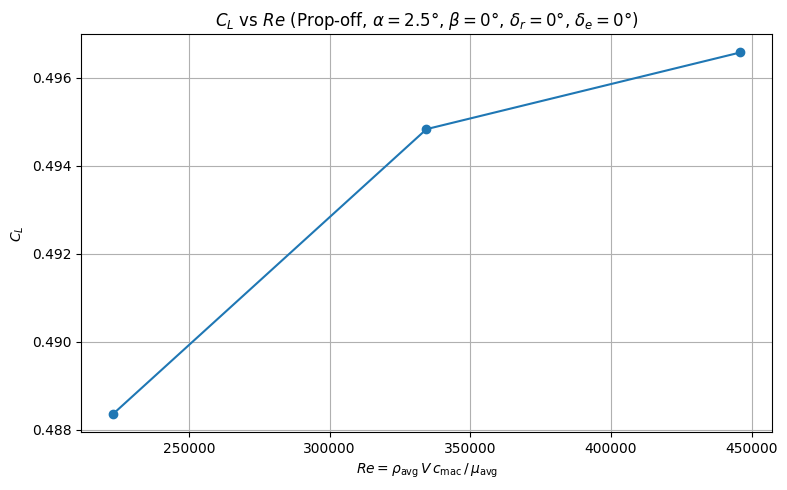

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sutherland's law ---
mu_ref = 1.716e-5  # Pa·s
T_ref  = 273.15    # K
S      = 110.4     # K

def sutherland_viscosity(T):
    return mu_ref * (T / T_ref)**1.5 * (T_ref + S) / (T + S)

# --- Representative tunnel conditions (averaged from prop-on data) ---
temps = [
    290.81, 290.5, 290.63, 290.71, 290.45, 290.68, 290.57, 290.54, 290.56,
    290.77, 290.76, 290.54, 290.61, 290.53, 290.53, 290.38, 290.77, 290.42,
    290.82, 290.31, 290.83, 290.77, 290.83, 290.59, 290.69, 289.29, 289.89,
    289.33, 289.37, 289.75, 289.05, 289.33, 289.45, 289.41, 289.41, 289.39,
    289.18, 289.41, 289.48, 289.55, 289.09, 289.4,  289.11, 289.29, 289.24,
    289.39, 289.55, 289.31, 289.75, 289.81, 289.23, 289.71, 289.86, 289.23,
    289.85
]
rhos = [
    1.2111837665772662, 1.2124162911880931, 1.211909932667162,
    1.211564445727421,  1.2134526039979827, 1.2123845995887763,
    1.2128315782593753, 1.213028753275484,  1.2129332677003728,
    1.211985376693565,  1.2120390414597149, 1.2130047723183783,
    1.2127125926478157, 1.213034532873517,  1.2130705055473072,
    1.2136371492818563, 1.212021319675703,  1.2134939840084806,
    1.2117650239582876, 1.2139537833203915, 1.211735336730007,
    1.2113024600329465, 1.2110765180038419, 1.21206476484882,
    1.2116478035619338, 1.2185471305276716, 1.2160731113350067,
    1.2183907064735384, 1.2182343256648152, 1.2166486644737404,
    1.2197155774698278, 1.218474990839042,  1.2179096580800357,
    1.2180779880835713, 1.2180659507882505, 1.218162170535493,
    1.2191672579972812, 1.2181261372648537, 1.2178195442593014,
    1.2175010680190128, 1.219558861881395,  1.2181682287001427,
    1.2194624456700003, 1.2186675534126223, 1.2188902649715678,
    1.2182103230444081, 1.2175251309693753, 1.2184869752778251,
    1.2166486644737404, 1.216432841075817,  1.2187878701265824,
    1.216816646064224,  1.2162230099778601, 1.2187999149132185,
    1.2162289133388524
]

T_avg   = np.mean(temps)
rho_avg = np.mean(rhos)
mu_avg  = sutherland_viscosity(T_avg)

print(f"T_avg   = {T_avg:.3f} K")
print(f"rho_avg = {rho_avg:.6f} kg/m³")
print(f"mu_avg  = {mu_avg:.4e} Pa·s")

# --- Wing MAC from manual ---
c_mac = 0.165  # m

# --- Filter prop-off: alpha=2.5, beta=0, rudder=0, elevator=0 ---
df_re = df_prop_off[
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["dR"]        == 0)   &
    (df_prop_off["dE"]        == 0)
].copy()
# Keep only the first sweep (lower original row indices)
df_re = df_re[df_re.index < 8000]

# Re varies through V; rho and mu are fixed representative averages
df_re["Re"] = rho_avg * df_re["V"] * c_mac / mu_avg
df_re = df_re.sort_values("Re")
def pick_row(group):
    v = group["V_round"].iloc[0]
    if v == 30.0:
        return group.iloc[[1]]  # second occurrence
    else:
        return group.iloc[[0]]  # first occurrence

df_re = df_re.groupby("V_round", group_keys=False).apply(pick_row)
print(df_re[["V_round", "V", "Re", "CL"]].to_string())

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_re["Re"], df_re["CL"], marker="o", linestyle="-")

ax.set_xlabel(r"$Re = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax.set_ylabel(r"$C_L$")
ax.set_title(r"$C_L$ vs $Re$ (Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$)")
ax.grid(True)
plt.tight_layout()
plt.savefig("plot_images/CL_vs_Re_propoff_AoA2.5.png", dpi=150)
plt.show()

CY Fit Function: y = 0.0034x + -0.0045
Correlation (r): 0.9952, R^2: 0.9904



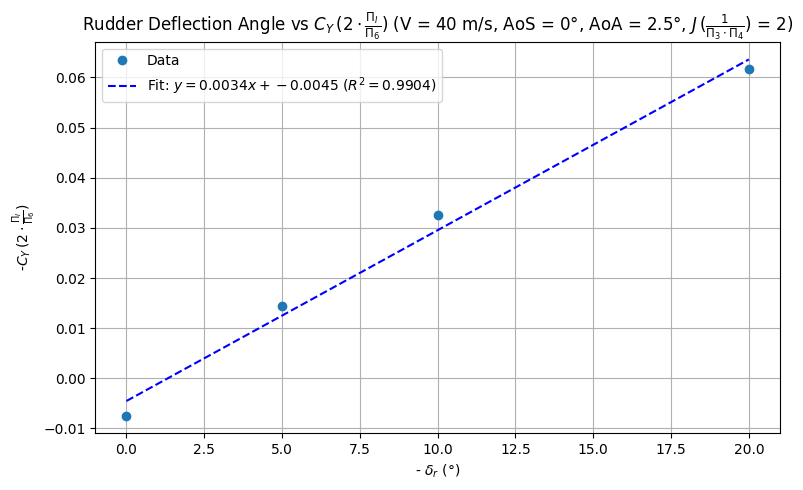

Saved to plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[(df["V_round"] == 40) & (df["AoS_round"] == 0) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]
group_sorted = df_filtered.sort_values("dR")

x = -group_sorted["dR"].values
y = -group_sorted["CYaw_FINAL"].values

# Calculate linear fit
slope_cy, intercept_cy = np.polyfit(x, y, 1)
r_matrix_cy = np.corrcoef(x, y)
r_val_cy = r_matrix_cy[0, 1]
r_squared_cy = r_val_cy**2

print(f"CY Fit Function: y = {slope_cy:.4f}x + {intercept_cy:.4f}")
print(f"Correlation (r): {r_val_cy:.4f}, R^2: {r_squared_cy:.4f}\n")

# Define as function for later use
def cy_from_dr(dr_neg):
    return slope_cy * dr_neg + intercept_cy

fig, ax = plt.subplots(figsize=(8, 5))

# Plot data
ax.plot(x, y, marker="o", linestyle="None", label="Data")

# Plot fit
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = cy_from_dr(x_fit)
ax.plot(
    x_fit, y_fit, 
    linestyle="--", 
    color="blue", 
    label=rf"Fit: $y = {slope_cy:.4f}x + {intercept_cy:.4f}$ ($R^2={r_squared_cy:.4f}$)"
)

ax.set_xlabel(r"- $\delta_r$ (°)")
ax.set_ylabel(r"-$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$")
ax.set_title(r"Rudder Deflection Angle vs $C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$ (V = 40 m/s, AoS = 0°, AoA = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png", dpi=150)
plt.show()
print("Saved to plot_images/rudder_vs_CY_V40_AoS0_AoA2.5_J2.png")


CMyaw Fit Function: y = 0.0015x + -0.0030
Correlation (r): 0.9941, R^2: 0.9882



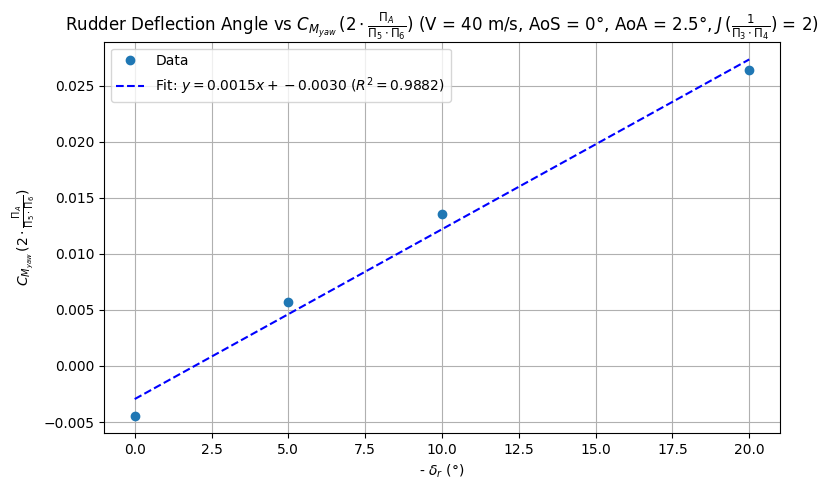

Saved to plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[(df["V_round"] == 40) & (df["AoS_round"] == 0) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]
group_sorted = df_filtered.sort_values("dR")

x = -group_sorted["dR"].values
y = group_sorted["CMyaw"].values

# Calculate linear fit
slope_cmyaw, intercept_cmyaw = np.polyfit(x, y, 1)
r_matrix_cmyaw = np.corrcoef(x, y)
r_val_cmyaw = r_matrix_cmyaw[0, 1]
r_squared_cmyaw = r_val_cmyaw**2

print(f"CMyaw Fit Function: y = {slope_cmyaw:.4f}x + {intercept_cmyaw:.4f}")
print(f"Correlation (r): {r_val_cmyaw:.4f}, R^2: {r_squared_cmyaw:.4f}\n")

# Define as function for later use
def cmyaw_from_dr(dr_neg):
    return slope_cmyaw * dr_neg + intercept_cmyaw

fig, ax = plt.subplots(figsize=(8, 5))

# Plot data
ax.plot(x, y, marker="o", linestyle="None", label="Data")

# Plot fit
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = cmyaw_from_dr(x_fit)
ax.plot(
    x_fit, y_fit, 
    linestyle="--", 
    color="blue", 
    label=rf"Fit: $y = {slope_cmyaw:.4f}x + {intercept_cmyaw:.4f}$ ($R^2={r_squared_cmyaw:.4f}$)"
)

ax.set_xlabel(r"- $\delta_r$ (°)")
ax.set_ylabel(r"$C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$")
ax.set_title(r"Rudder Deflection Angle vs $C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$ (V = 40 m/s, AoS = 0°, AoA = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png", dpi=150)
plt.show()
print("Saved to plot_images/rudder_vs_CMyaw_V40_AoS0_AoA2.5_J2.png")


dR = -20.0° | Fit Function: y = -0.0047x + 0.0261 | r = -0.9983, R^2 = 0.9966
dR = -10.0° | Fit Function: y = -0.0049x + 0.0132 | r = -0.9987, R^2 = 0.9973
dR = -5.0° | Fit Function: y = -0.0049x + 0.0054 | r = -0.9989, R^2 = 0.9978
dR = 0.0° | Fit Function: y = -0.0049x + -0.0051 | r = -0.9995, R^2 = 0.9990

(Functions can be accessed via `cmyaw_from_aos_funcs[dR_value](aos)`)


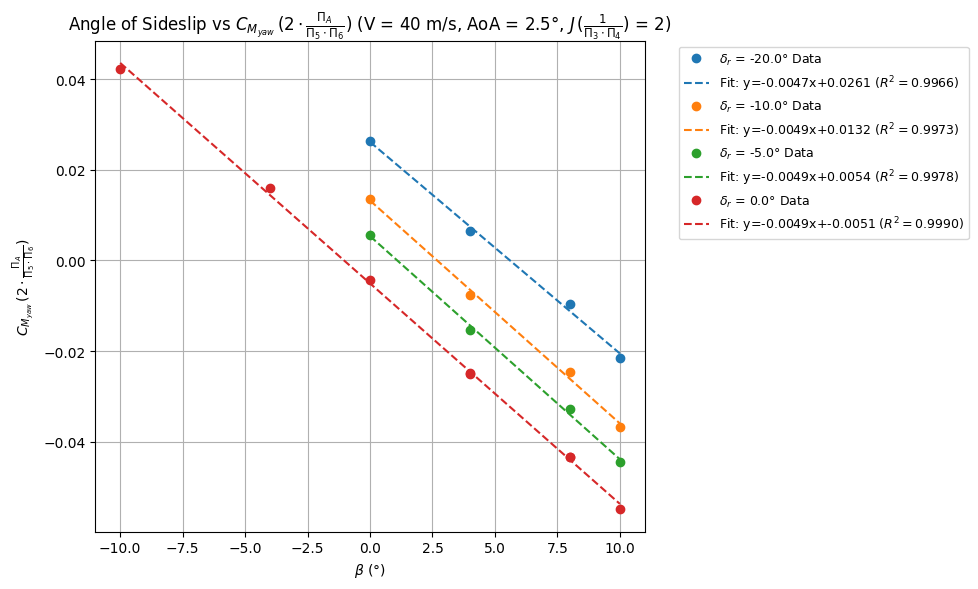

Saved to plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[(df["V_round"] == 40) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(10, 6))

# Dictionary to store interpolation functions for each rudder
cmyaw_from_aos_funcs = {}

for rudder, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("AoS_round")
    
    x = group_sorted["AoS_round"].values
    y = group_sorted["CMyaw"].values
    
    # Calculate linear fit
    slope, intercept = np.polyfit(x, y, 1)
    r_matrix = np.corrcoef(x, y)
    r_val = r_matrix[0, 1]
    r_squared = r_val**2
    
    print(f"dR = {rudder}° | Fit Function: y = {slope:.4f}x + {intercept:.4f} | r = {r_val:.4f}, R^2 = {r_squared:.4f}")
    
    # Store function in dictionary for later use
    cmyaw_from_aos_funcs[rudder] = lambda aos, m=slope, c=intercept: m * aos + c
    
    # Plot original data
    # Compatible with newer matplotlib (avoid private ax._get_lines.prop_cycler)
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
    color = colors[(len(cmyaw_from_aos_funcs) - 1) % len(colors)]
    ax.plot(
        x, y,
        marker="o",
        linestyle="None",
        color=color,
        label=fr"$\delta_r$ = {rudder}° Data",
    )
    
    # Plot linear fit
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        color=color,
        label=fr"Fit: y={slope:.4f}x+{intercept:.4f} ($R^2={r_squared:.4f}$)",
    )

print("\n(Functions can be accessed via `cmyaw_from_aos_funcs[dR_value](aos)`)")

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$")
ax.set_title(r"Angle of Sideslip vs $C_{M_{yaw}} \, (2 \cdot \frac{\Pi_A}{\Pi_5 \cdot \Pi_6})$ (V = 40 m/s, AoA = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")

# Place legend outside due to many elements
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png", dpi=150)
plt.show()
print("Saved to plot_images/AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png")



=== CL_FINAL interpolation (degree 1) ===
CL_FINAL | J=1.6, dR=-10.0: y(alpha) = 0.1141*x + 0.2008 | R^2 = 0.99887
CL_FINAL | J=1.6, dR=0.0: y(alpha) = 0.1136*x + 0.2038 | R^2 = 0.99861
CL_FINAL | J=2.4, dR=-10.0: y(alpha) = 0.1101*x + 0.1955 | R^2 = 0.99885
CL_FINAL | J=2.4, dR=0.0: y(alpha) = 0.1100*x + 0.1971 | R^2 = 0.99872
CL_FINAL | Prop-off: y(alpha) = 0.1061*x + 0.2071 | R^2 = 0.99846


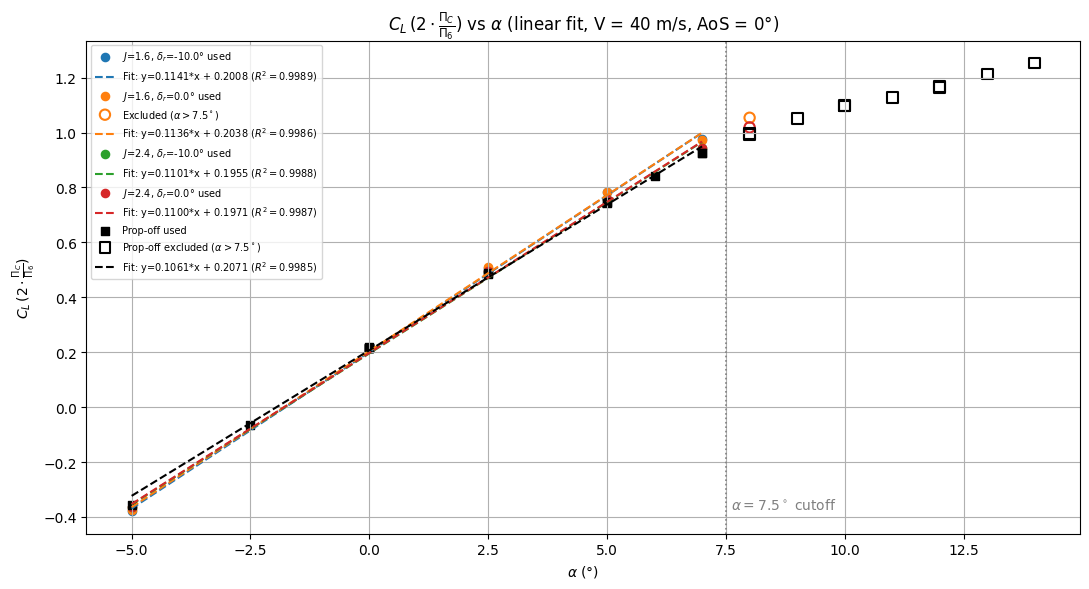

Saved to plot_images/CL_vs_alpha_linear_interp_upto7p5.png

=== CD_FINAL interpolation (degree 2) ===
CD_FINAL | J=1.6, dR=-10.0: y(alpha) = 0.0007*x^2 + 0.0011*x - 0.0452 | R^2 = 0.99996
CD_FINAL | J=1.6, dR=0.0: y(alpha) = 0.0007*x^2 + 0.0011*x - 0.0484 | R^2 = 0.99833
CD_FINAL | J=2.4, dR=-10.0: y(alpha) = 0.0006*x^2 + 0.0013*x + 0.0511 | R^2 = 0.99997
CD_FINAL | J=2.4, dR=0.0: y(alpha) = 0.0006*x^2 + 0.0014*x + 0.0475 | R^2 = 0.99995
CD_FINAL | Prop-off: y(alpha) = 0.0006*x^2 + 0.0012*x + 0.0457 | R^2 = 0.99965


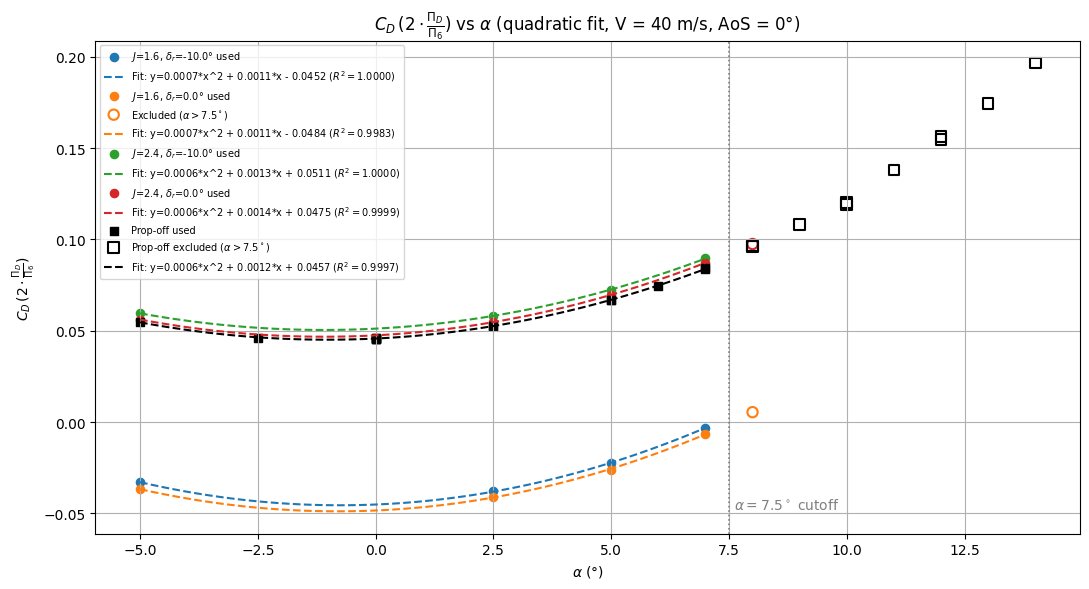

Saved to plot_images/CD_vs_alpha_quadratic_interp_upto7p5.png

=== CLCD interpolation (degree 2) ===
CLCD | J=1.6, dR=-10.0: y(alpha) = -5.9619*x^2 - 11.7360*x + 97.7234 | R^2 = 0.87038
CLCD | J=1.6, dR=0.0: y(alpha) = -2.6694*x^2 - 6.9731*x + 40.3101 | R^2 = 0.90311
CLCD | J=2.4, dR=-10.0: y(alpha) = -0.1246*x^2 + 1.6433*x + 5.1991 | R^2 = 0.99983
CLCD | J=2.4, dR=0.0: y(alpha) = -0.1405*x^2 + 1.7264*x + 5.6659 | R^2 = 0.99996
CLCD | Prop-off: y(alpha) = -0.1246*x^2 + 1.8066*x + 4.8916 | R^2 = 0.99163


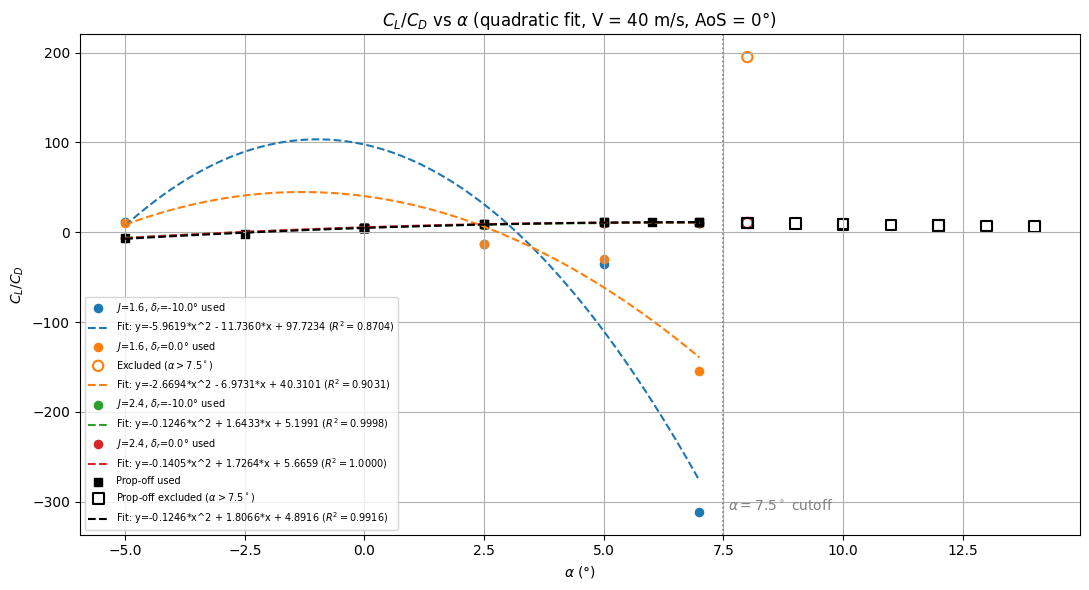

Saved to plot_images/CLCD_vs_alpha_quadratic_interp_upto7p5.png

Interpolation functions are stored in `interpolation_functions`.
Example usage: interpolation_functions['CL_FINAL'][(1.6, 0)](4.0)


In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Make sure output folder exists
os.makedirs("plot_images", exist_ok=True)

# -----------------------------------
# Create rounded columns if missing
# -----------------------------------
if "V_round" not in df.columns:
    df["V_round"] = df["V"].round()

if "AoS_round" not in df.columns:
    df["AoS_round"] = df["AoS"].round()

if "AoA_round" not in df.columns:
    df["AoA_round"] = df["AoA"].round(1)

if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()

if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()

if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# -----------------------------------
# Filter data
# -----------------------------------
df_filtered = df[
    (df["V_round"] == 40) &
    (df["J_round"] != 2) &
    (df["AoS_round"] == 0)
] .copy()

df_prop_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
] .copy()

valid_groups = (
    df_filtered.groupby(["J_round", "dR"])["AoA_round"]
    .nunique()
    .reset_index()
)
valid_groups = valid_groups[valid_groups["AoA_round"] > 1]

df_prop_off_filtered = df_prop_off_filtered.sort_values("AoA_round")

# -----------------------------------
# Build CL/CD and interpolation containers
# -----------------------------------
df_filtered = df_filtered.copy()
df_prop_off_filtered = df_prop_off_filtered.copy()

df_filtered["CLCD"] = df_filtered["CL_FINAL"] / df_filtered["CD_FINAL"].replace(0, np.nan)
df_prop_off_filtered["CLCD"] = df_prop_off_filtered["CL_FINAL"] / df_prop_off_filtered["CD_FINAL"].replace(0, np.nan)

alpha_fit_max = 7.5
interpolation_functions = {
    "CL_FINAL": {},
    "CD_FINAL": {},
    "CLCD": {},
}
interpolation_coeffs = {
    "CL_FINAL": {},
    "CD_FINAL": {},
    "CLCD": {},
}

def poly_eqn_string(coeffs):
    degree = len(coeffs) - 1
    terms = []
    for i, c in enumerate(coeffs):
        power = degree - i
        if power == 0:
            terms.append(f"{c:.4f}")
        elif power == 1:
            terms.append(f"{c:.4f}*x")
        else:
            terms.append(f"{c:.4f}*x^{power}")
    return " + ".join(terms).replace("+ -", "- ")

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return 1.0 - ss_res / ss_tot

def fit_and_plot_vs_alpha(y_col, y_label, title, save_path, degree):
    fig, ax = plt.subplots(figsize=(11, 6))
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"] * 10)

    shown_excluded_label = False
    print(f"\n=== {y_col} interpolation (degree {degree}) ===")

    for idx, (_, row) in enumerate(valid_groups.iterrows()):
        j_val = row["J_round"]
        rudder_val = row["dR"]

        group = df_filtered[
            (df_filtered["J_round"] == j_val) &
            (df_filtered["dR"] == rudder_val)
        ].sort_values("AoA_round")

        x_all = group["AoA_round"].to_numpy(dtype=float)
        y_all = group[y_col].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_all) & np.isfinite(y_all)
        x_all = x_all[finite_mask]
        y_all = y_all[finite_mask]

        used_mask = x_all <= alpha_fit_max
        x_used, y_used = x_all[used_mask], y_all[used_mask]
        x_excl, y_excl = x_all[~used_mask], y_all[~used_mask]

        color = colors[idx % len(colors)]
        base_label = fr"$J$={j_val}, $\delta_r$={rudder_val}°"

        ax.scatter(x_used, y_used, color=color, s=35, label=base_label + " used")
        if len(x_excl) > 0:
            excl_label = r"Excluded ($\alpha > 7.5^\circ$)" if not shown_excluded_label else None
            ax.scatter(
                x_excl, y_excl,
                facecolors="none",
                edgecolors=color,
                s=55,
                linewidths=1.5,
                label=excl_label,
            )
            shown_excluded_label = True

        min_points = degree + 1
        if len(x_used) < min_points:
            print(
                f"{y_col} | J={j_val}, dR={rudder_val}: skipped, "
                f"need >= {min_points} points with alpha <= {alpha_fit_max}"
            )
            continue

        coeffs = np.polyfit(x_used, y_used, degree)
        fit_func = np.poly1d(coeffs)
        y_hat = fit_func(x_used)
        r2 = compute_r2(y_used, y_hat)
        eqn_str = poly_eqn_string(coeffs)

        interpolation_coeffs[y_col][(j_val, rudder_val)] = coeffs
        interpolation_functions[y_col][(j_val, rudder_val)] = (
            lambda alpha, c=coeffs: np.polyval(c, np.asarray(alpha, dtype=float))
        )

        x_fit = np.linspace(x_used.min(), x_used.max(), 100)
        y_fit = fit_func(x_fit)
        ax.plot(
            x_fit, y_fit,
            linestyle="--",
            color=color,
            label=fr"Fit: y={eqn_str} ($R^2={r2:.4f}$)"
        )

        print(
            f"{y_col} | J={j_val}, dR={rudder_val}: "
            f"y(alpha) = {eqn_str} | R^2 = {r2:.5f}"
        )

    # Prop-off interpolation for reference
    x_off_all = df_prop_off_filtered["AoA_round"].to_numpy(dtype=float)
    y_off_all = df_prop_off_filtered[y_col].to_numpy(dtype=float)
    finite_off = np.isfinite(x_off_all) & np.isfinite(y_off_all)
    x_off_all = x_off_all[finite_off]
    y_off_all = y_off_all[finite_off]

    used_off = x_off_all <= alpha_fit_max
    x_off_used, y_off_used = x_off_all[used_off], y_off_all[used_off]
    x_off_excl, y_off_excl = x_off_all[~used_off], y_off_all[~used_off]

    ax.scatter(
        x_off_used, y_off_used,
        color="black",
        marker="s",
        s=35,
        label="Prop-off used",
    )
    if len(x_off_excl) > 0:
        excl_label = r"Prop-off excluded ($\alpha > 7.5^\circ$)"
        ax.scatter(
            x_off_excl, y_off_excl,
            facecolors="none",
            edgecolors="black",
            marker="s",
            s=60,
            linewidths=1.5,
            label=excl_label,
        )

    min_points = degree + 1
    if len(x_off_used) >= min_points:
        coeffs_off = np.polyfit(x_off_used, y_off_used, degree)
        fit_off = np.poly1d(coeffs_off)
        y_hat_off = fit_off(x_off_used)
        r2_off = compute_r2(y_off_used, y_hat_off)
        eqn_off_str = poly_eqn_string(coeffs_off)

        interpolation_coeffs[y_col][("prop_off", 0)] = coeffs_off
        interpolation_functions[y_col][("prop_off", 0)] = (
            lambda alpha, c=coeffs_off: np.polyval(c, np.asarray(alpha, dtype=float))
        )

        x_fit_off = np.linspace(x_off_used.min(), x_off_used.max(), 100)
        y_fit_off = fit_off(x_fit_off)
        ax.plot(
            x_fit_off, y_fit_off,
            linestyle="--",
            color="black",
            label=fr"Fit: y={eqn_off_str} ($R^2={r2_off:.4f}$)"
        )

        print(
            f"{y_col} | Prop-off: y(alpha) = {eqn_off_str} "
            f"| R^2 = {r2_off:.5f}"
        )
    else:
        print(
            f"{y_col} | Prop-off: skipped, need >= {min_points} points "
            f"with alpha <= {alpha_fit_max}"
        )

    ax.axvline(alpha_fit_max, color="gray", linestyle=":", linewidth=1.2)
    ax.text(
        alpha_fit_max + 0.1,
        ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
        r"$\alpha=7.5^\circ$ cutoff",
        color="gray",
    )

    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=1, loc="best")
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved to {save_path}")

# -----------------------------------
# Plot 1: CL vs alpha (linear interpolation)
# -----------------------------------
fit_and_plot_vs_alpha(
    y_col="CL_FINAL",
    y_label=r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$",
    title=r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$ vs $\alpha$ (linear fit, V = 40 m/s, AoS = 0°)",
    save_path="plot_images/CL_vs_alpha_linear_interp_upto7p5.png",
    degree=1
)

# -----------------------------------
# Plot 2: CD vs alpha (quadratic interpolation)
# -----------------------------------
fit_and_plot_vs_alpha(
    y_col="CD_FINAL",
    y_label=r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$",
    title=r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$ vs $\alpha$ (quadratic fit, V = 40 m/s, AoS = 0°)",
    save_path="plot_images/CD_vs_alpha_quadratic_interp_upto7p5.png",
    degree=2
)

# -----------------------------------
# Plot 3: CL/CD vs alpha (quadratic interpolation)
# -----------------------------------
fit_and_plot_vs_alpha(
    y_col="CLCD",
    y_label=r"$C_L / C_D$",
    title=r"$C_L / C_D$ vs $\alpha$ (quadratic fit, V = 40 m/s, AoS = 0°)",
    save_path="plot_images/CLCD_vs_alpha_quadratic_interp_upto7p5.png",
    degree=2
)

print("\nInterpolation functions are stored in `interpolation_functions`.")
print("Example usage: interpolation_functions['CL_FINAL'][(1.6, 0)](4.0)")

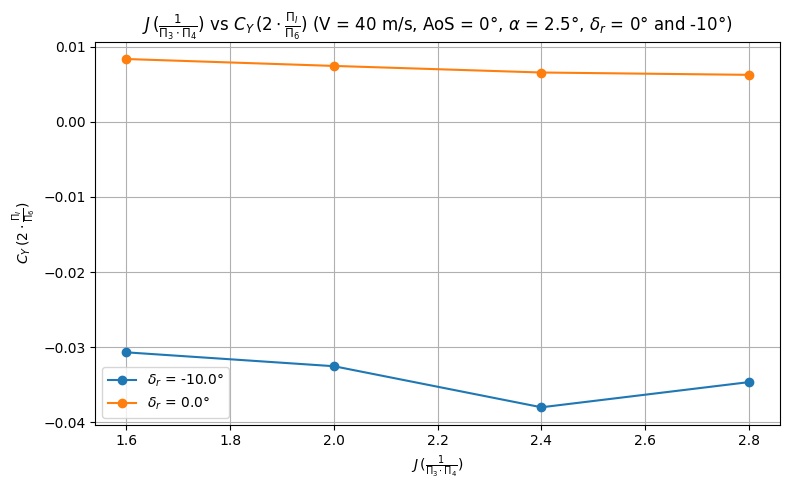

Saved to plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png


In [79]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["dR"].isin([0, -10]))
]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder_val, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("J_round")
    ax.plot(
        group_sorted["J_round"],
        group_sorted["CYaw_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_r$ = {rudder_val}°",
    )

ax.set_xlabel(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$")
ax.set_ylabel(r"$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$")
ax.set_title(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ vs $C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$ (V = 40 m/s, AoS = 0°, $\alpha$ = 2.5°, $\delta_r$ = 0° and -10°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png", dpi=150)
plt.show()
print("Saved to plot_images/J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10.png")


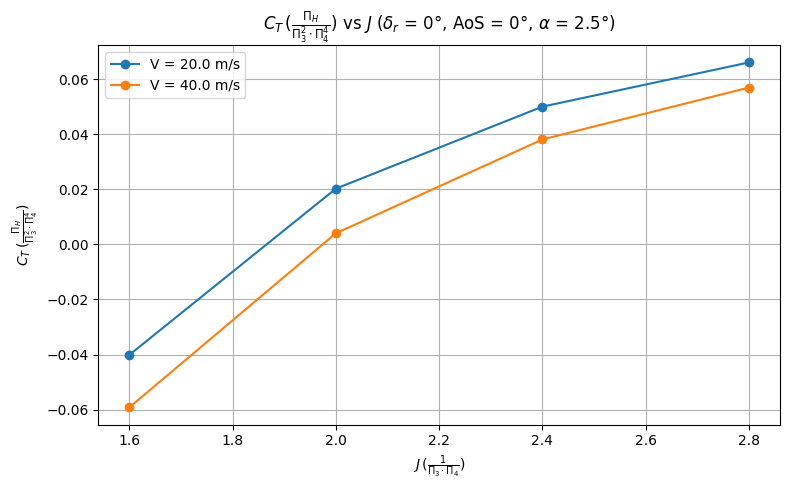

Saved to plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png


In [80]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["dR"] == 0)
]

fig, ax = plt.subplots(figsize=(8, 5))

for v_val, group in df_filtered.groupby("V_round"):
    group_sorted = group.sort_values("J_round")
    ax.plot(
        group_sorted["J_round"],
        group_sorted["CT"],
        marker="o",
        linestyle="-",
        label=f"V = {v_val} m/s",
    )

ax.set_xlabel(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$")
ax.set_ylabel(r"$C_T \, (\frac{\Pi_H}{\Pi_3^2 \cdot \Pi_4^4})$")
ax.set_title(r"$C_T \, (\frac{\Pi_H}{\Pi_3^2 \cdot \Pi_4^4})$ vs $J$ ($\delta_r$ = 0°, AoS = 0°, $\alpha$ = 2.5°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png")


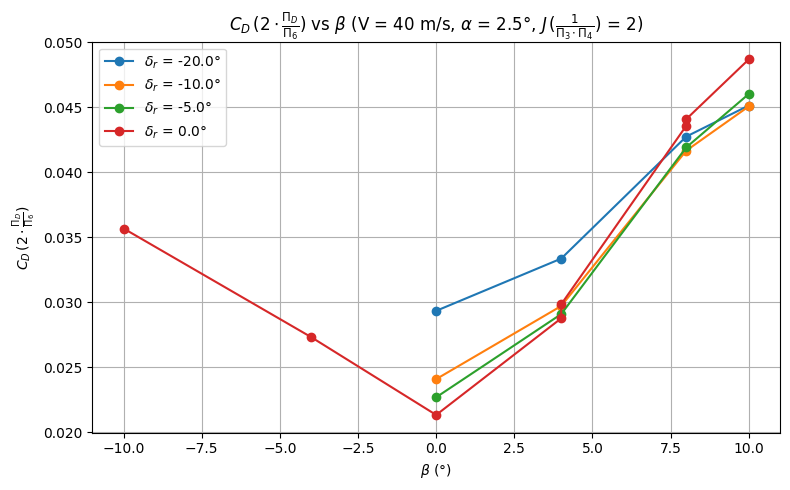

Saved to plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png


In [81]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoA_round"] == 2.5) &
    (df["J_round"] == 2)
]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder_val, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CD_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_r$ = {rudder_val}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$")
ax.set_title(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$ vs $\beta$ (V = 40 m/s, $\alpha$ = 2.5°, $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png", dpi=150)
plt.show()
print("Saved to plot_images/CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png")


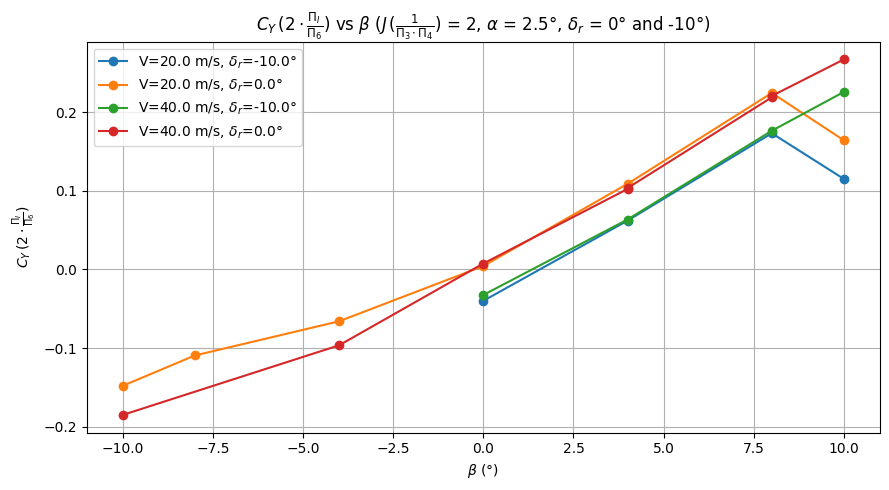

Saved to plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png


In [82]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["dR"].isin([0, -10])) &
    (df["J_round"] == 2) &
    (df["AoA_round"] == 2.5)
]

fig, ax = plt.subplots(figsize=(9, 5))

for (v_val, rudder_val), group in df_filtered.groupby(["V_round", "dR"]):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CYaw_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"V={v_val} m/s, $\delta_r$={rudder_val}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$")
ax.set_title(r"$C_Y \, (2 \cdot \frac{\Pi_I}{\Pi_6})$ vs $\beta$ ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2, $\alpha$ = 2.5°, $\delta_r$ = 0° and -10°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png", dpi=150)
plt.show()
print("Saved to plot_images/CY_vs_AoS_V20_V40_rudder0_m10_J2_AoA2.5.png")


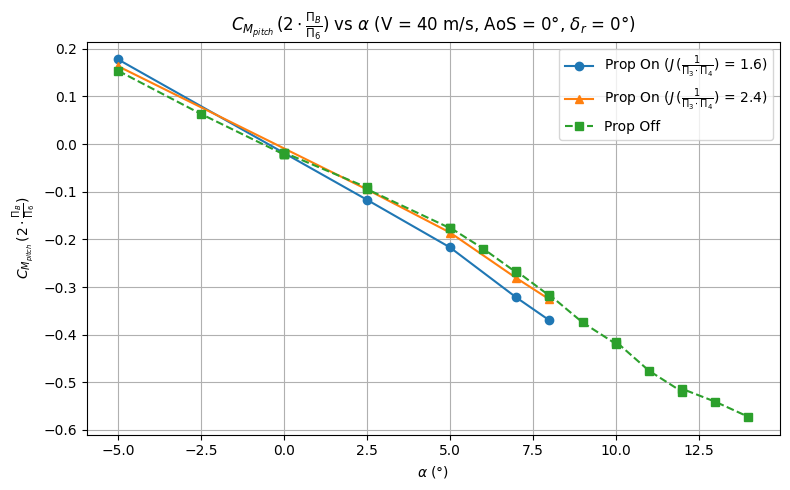

Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png


In [88]:
import matplotlib.pyplot as plt

# Filter prop on J=1.6
df_on_filtered_16 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 1.6)
].sort_values("AoA_round")

# Filter prop on J=2.4
df_on_filtered_24 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 2.4)
].sort_values("AoA_round")

# Filter prop off
df_off_filtered = df_prop_off[
    (round(df_prop_off["V"]) == 40) & 
    (round(df_prop_off["AoS"]) == 0) & 
    (df_prop_off["dE"] == 0) &
    (df_prop_off["dR"] == 0)
].sort_values("AoA")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_on_filtered_16["AoA_round"],
    df_on_filtered_16["CMpitch_FINAL"],
    marker="o",
    linestyle="-",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 1.6)"
    )

ax.plot(
    df_on_filtered_24["AoA_round"],
    df_on_filtered_24["CMpitch_FINAL"],
    marker="^",
    linestyle="-",
    label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2.4)"
)

ax.plot(
    df_off_filtered["AoA"],
    df_off_filtered["CMpitch_FINAL"],
    marker="s",
    linestyle="--",
    label="Prop Off"
)

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ vs $\alpha$ (V = 40 m/s, AoS = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0.png")

T_avg   = 289.977 K
rho_avg = 1.215456 kg/m³
mu_avg  = 1.7981e-05 Pa·s
      V_round          V             Re  CL_FINAL
776      20.0  19.994741  223010.738613  0.472726
2177     30.0  29.982692  334411.051566  0.482000
3632     40.0  39.989745  446024.413384  0.485019


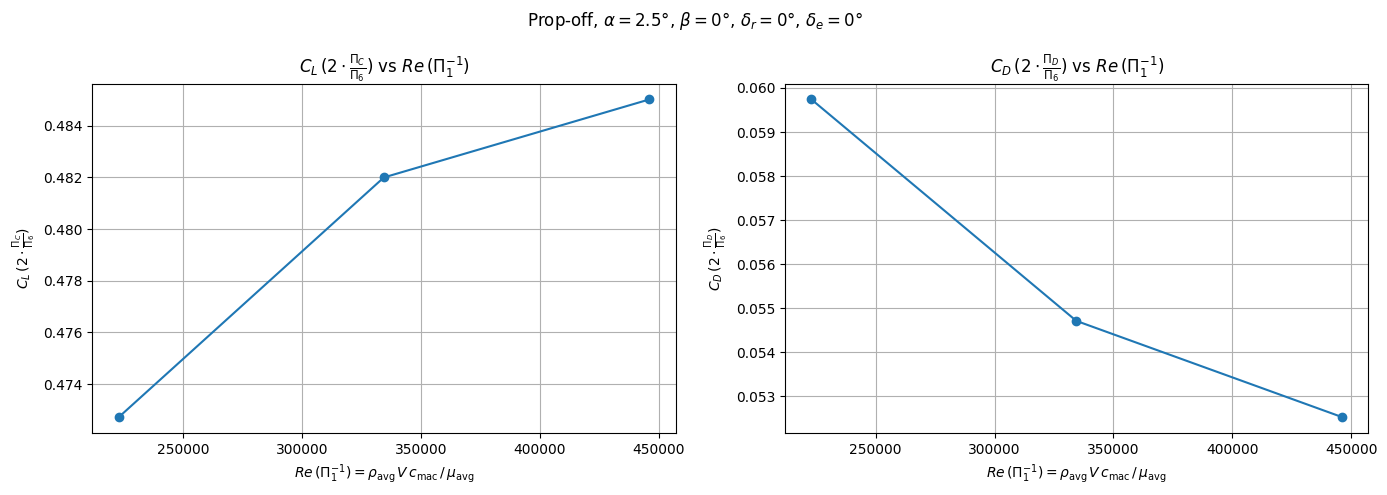

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sutherland's law ---
mu_ref = 1.716e-5  # Pa·s
T_ref  = 273.15    # K
S      = 110.4     # K

def sutherland_viscosity(T):
    return mu_ref * (T / T_ref)**1.5 * (T_ref + S) / (T + S)

# --- Representative tunnel conditions (averaged from prop-on data) ---
temps = [
    290.81, 290.5, 290.63, 290.71, 290.45, 290.68, 290.57, 290.54, 290.56,
    290.77, 290.76, 290.54, 290.61, 290.53, 290.53, 290.38, 290.77, 290.42,
    290.82, 290.31, 290.83, 290.77, 290.83, 290.59, 290.69, 289.29, 289.89,
    289.33, 289.37, 289.75, 289.05, 289.33, 289.45, 289.41, 289.41, 289.39,
    289.18, 289.41, 289.48, 289.55, 289.09, 289.4,  289.11, 289.29, 289.24,
    289.39, 289.55, 289.31, 289.75, 289.81, 289.23, 289.71, 289.86, 289.23,
    289.85
]
rhos = [
    1.2111837665772662, 1.2124162911880931, 1.211909932667162,
    1.211564445727421,  1.2134526039979827, 1.2123845995887763,
    1.2128315782593753, 1.213028753275484,  1.2129332677003728,
    1.211985376693565,  1.2120390414597149, 1.2130047723183783,
    1.2127125926478157, 1.213034532873517,  1.2130705055473072,
    1.2136371492818563, 1.212021319675703,  1.2134939840084806,
    1.2117650239582876, 1.2139537833203915, 1.211735336730007,
    1.2113024600329465, 1.2110765180038419, 1.21206476484882,
    1.2116478035619338, 1.2185471305276716, 1.2160731113350067,
    1.2183907064735384, 1.2182343256648152, 1.2166486644737404,
    1.2197155774698278, 1.218474990839042,  1.2179096580800357,
    1.2180779880835713, 1.2180659507882505, 1.218162170535493,
    1.2191672579972812, 1.2181261372648537, 1.2178195442593014,
    1.2175010680190128, 1.219558861881395,  1.2181682287001427,
    1.2194624456700003, 1.2186675534126223, 1.2188902649715678,
    1.2182103230444081, 1.2175251309693753, 1.2184869752778251,
    1.2166486644737404, 1.216432841075817,  1.2187878701265824,
    1.216816646064224,  1.2162230099778601, 1.2187999149132185,
    1.2162289133388524
]

T_avg   = np.mean(temps)
rho_avg = np.mean(rhos)
mu_avg  = sutherland_viscosity(T_avg)

print(f"T_avg   = {T_avg:.3f} K")
print(f"rho_avg = {rho_avg:.6f} kg/m³")
print(f"mu_avg  = {mu_avg:.4e} Pa·s")

# --- Wing MAC from manual ---
c_mac = 0.165  # m

# --- Filter prop-off: alpha=2.5, beta=0, rudder=0, elevator=0 ---
df_re = df_prop_off[
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["dR"]        == 0)   &
    (df_prop_off["dE"]        == 0)
].copy()


# Re varies through V; rho and mu are fixed representative averages
df_re["Re"] = rho_avg * df_re["V"] * c_mac / mu_avg
df_re = df_re.sort_values("Re")
# Keep only the lower CL point per velocity (one sweep)
df_re = df_re.loc[df_re.groupby("V_round")["CL_FINAL"].idxmin()]
df_re = df_re.sort_values("Re")

print(df_re[["V_round", "V", "Re", "CL_FINAL"]].to_string())

# --- Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(df_re["Re"], df_re["CL_FINAL"], marker="o", linestyle="-")

# ax.set_xlabel(r"$Re \, (\Pi_1^{-1}) = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
# ax.set_ylabel(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$")
# ax.set_title(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$ vs $Re \, (\Pi_1^{-1})$ (Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$)")
# ax.grid(True)
# plt.tight_layout()
# plt.savefig("plot_images/CL_vs_Re_propoff_AoA2.5.png", dpi=150)
# plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_re["Re"], df_re["CL_FINAL"], marker="o", linestyle="-")
ax1.set_xlabel(r"$Re \, (\Pi_1^{-1}) = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax1.set_ylabel(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$")
ax1.set_title(r"$C_L \, (2 \cdot \frac{\Pi_C}{\Pi_6})$ vs $Re \, (\Pi_1^{-1})$")
ax1.grid(True)

ax2.plot(df_re["Re"], df_re["CD_FINAL"], marker="o", linestyle="-")
ax2.set_xlabel(r"$Re \, (\Pi_1^{-1}) = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax2.set_ylabel(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$")
ax2.set_title(r"$C_D \, (2 \cdot \frac{\Pi_D}{\Pi_6})$ vs $Re \, (\Pi_1^{-1})$")
ax2.grid(True)

fig.suptitle(r"Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$")
plt.tight_layout()
plt.savefig("plot_images/CL_CD_vs_Re_propoff_AoA2.5.png", dpi=150)
plt.show()

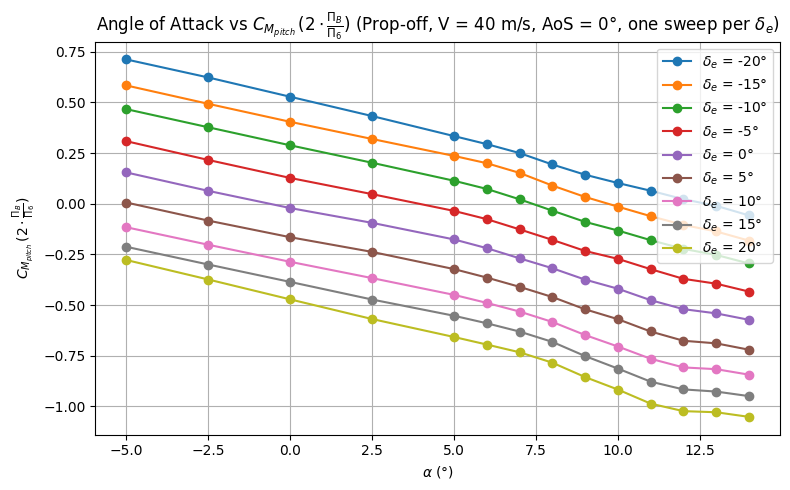

         AoA  AoS          V  dE  dR        CL        CD      CYaw    CMroll   CMpitch     CMyaw  CD_modeloff  CY_modeloff  CL_modeloff  CMroll_modeloff  CMpitch_modeloff  CMyaw_modeloff  modeloff_correction_found  CD_uncorrected  CL_uncorrected  CMroll_uncorrected  CMpitch_uncorrected  CMyaw_uncorrected  V_round  AoA_round  AoS_round       CL2  fit_used   CD0_fit     k_fit    R2_fit  CD_fit_pred   CDi_fit       esb   CL2_fit  CDsep_fit       ewb  e_total_blockage    V_FINAL  CL_blockage_corr  CD_blockage_corr  CYaw_FINAL  CMroll_FINAL  CMpitch_blockage_corr  CMyaw_FINAL  CL_alpha_per_deg_tailoff  CL_alpha_per_rad_tailoff  delta_alpha_sc_rad  delta_alpha_sc_deg  AoA_FINAL  delta_CL_sc  delta_CMpitch_sc  CL_FINAL  CMpitch_blockage_corr_sc_corr  streamline_curvature_data_found  delta_alpha_dw_deg  delta_alpha_dw_rad  delta_CD_dw  AoA_downwash_corr  CD_FINAL  downwash_data_found  CLw_tailoff  delta_alpha_tail_rad  delta_alpha_tail_deg  delta_CMpitch_tail  AoA_tail_corr  CMpitch_FINAL  tai

In [10]:
import os
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("plot_images", exist_ok=True)

# Create rounded columns if missing
if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()

if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()

if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# Base filter
df_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0)
].copy()

# Keep original row index
df_filtered = df_filtered.sort_index()

def select_best_sweep(group, gap_threshold=100):
    """
    Split one dE group into separate sweeps based on jumps in original row index.
    Keep the sweep with the largest AoA range.
    If tied, keep the one with the most data points.
    Then deduplicate by AoA_round, keeping the first of any pair.
    """
    group = group.sort_index().copy()

    # Split into sweep blocks when row jump is large
    row_jump = group.index.to_series().diff().fillna(0)
    group["sweep_id"] = (row_jump > gap_threshold).cumsum()

    best_block = None
    best_range = -1
    best_npoints = -1

    for _, block in group.groupby("sweep_id"):
        aoa_range = block["AoA"].max() - block["AoA"].min()
        npoints = len(block)

        if (aoa_range > best_range) or (aoa_range == best_range and npoints > best_npoints):
            best_block = block.copy()
            best_range = aoa_range
            best_npoints = npoints

    # Deduplicate: if two consecutive rows share the same AoA_round, keep the first
    best_block = best_block.sort_index()
    best_block = best_block.drop_duplicates(subset="AoA_round", keep="first")

    return best_block

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

selected_sweeps = {}

# Plot one cleaned sweep for each elevator deflection
for de, group in df_filtered.groupby("dE"):
    best_sweep = select_best_sweep(group, gap_threshold=100)
    best_sweep = best_sweep.sort_values("AoA_round")

    selected_sweeps[de] = best_sweep.copy()

    ax.plot(
        best_sweep["AoA_round"],
        best_sweep["CMpitch_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_e$ = {de}°",
    )

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"Angle of Attack vs $C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ (Prop-off, V = 40 m/s, AoS = 0°, one sweep per $\delta_e$)")
ax.legend()
ax.grid(True)

plt.tight_layout()
save_path = "plot_images/AoA_vs_CMpitch_propoff_V40_AoS0_all_elevators_cleaned.png"
plt.savefig(save_path, dpi=150)
plt.show()

print(selected_sweeps.get(-10, pd.DataFrame()).to_string(index=True))
print("\nChosen sweep per elevator deflection:")
for de, sweep in selected_sweeps.items():
    print(
        f"dE = {de:>5}: rows {sweep.index.min()+2} to {sweep.index.max()+2}, "
        f"AoA range = {sweep['AoA'].min():.3f} to {sweep['AoA'].max():.3f}, "
        f"points = {len(sweep)}"
    )


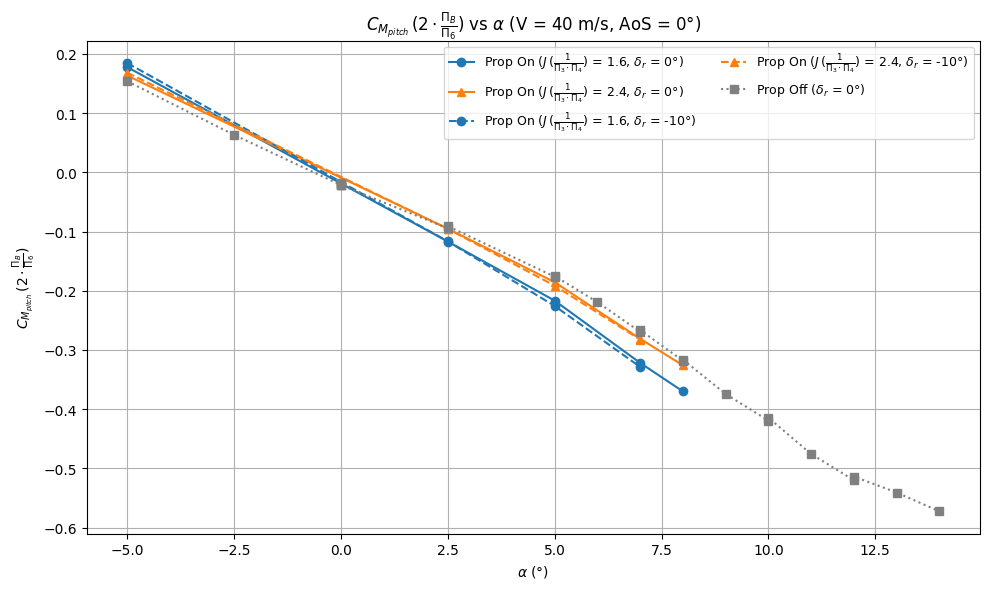

Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png


In [14]:
import matplotlib.pyplot as plt

def select_best_sweep(group, gap_threshold=100):
    if group is None or group.empty:
        return group
    
    group = group.sort_index().copy()
    row_jump = group.index.to_series().diff().fillna(0)
    group["sweep_id"] = (row_jump > gap_threshold).cumsum()

    best_block = None
    best_range = -1
    best_npoints = -1

    for _, block in group.groupby("sweep_id"):
        aoa_range = block["AoA"].max() - block["AoA"].min()
        npoints = len(block)

        if (aoa_range > best_range) or (aoa_range == best_range and npoints > best_npoints):
            best_block = block.copy()
            best_range = aoa_range
            best_npoints = npoints

    return best_block

# Filter prop on J=1.6, dR=0
df_on_filtered_16_r0 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 1.6)
]
df_on_filtered_16_r0 = select_best_sweep(df_on_filtered_16_r0)
if df_on_filtered_16_r0 is not None: df_on_filtered_16_r0 = df_on_filtered_16_r0.sort_values("AoA_round")

# Filter prop on J=2.4, dR=0
df_on_filtered_24_r0 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 2.4)
]
df_on_filtered_24_r0 = select_best_sweep(df_on_filtered_24_r0)
if df_on_filtered_24_r0 is not None: df_on_filtered_24_r0 = df_on_filtered_24_r0.sort_values("AoA_round")

# Filter prop on J=1.6, dR=-10
df_on_filtered_16_rm10 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == -10) & 
    (df["J_round"] == 1.6)
]
df_on_filtered_16_rm10 = select_best_sweep(df_on_filtered_16_rm10)
if df_on_filtered_16_rm10 is not None: df_on_filtered_16_rm10 = df_on_filtered_16_rm10.sort_values("AoA_round")

# Filter prop on J=2.4, dR=-10
df_on_filtered_24_rm10 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == -10) & 
    (df["J_round"] == 2.4)
]
df_on_filtered_24_rm10 = select_best_sweep(df_on_filtered_24_rm10)
if df_on_filtered_24_rm10 is not None: df_on_filtered_24_rm10 = df_on_filtered_24_rm10.sort_values("AoA_round")

# Filter prop off, dR=0
df_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) & 
    (df_prop_off["AoS_round"] == 0) & 
    (df_prop_off["dE"] == 0) &
    (df_prop_off["dR"] == 0)
]
df_off_filtered = select_best_sweep(df_off_filtered)
if df_off_filtered is not None: df_off_filtered = df_off_filtered.sort_values("AoA_round")

fig, ax = plt.subplots(figsize=(10, 6))

if df_on_filtered_16_r0 is not None and not df_on_filtered_16_r0.empty:
    ax.plot(
        df_on_filtered_16_r0["AoA_round"],
        df_on_filtered_16_r0["CMpitch_FINAL"],
        marker="o",
        linestyle="-",
        color="C0",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 1.6, $\delta_r$ = 0°)"
    )

if df_on_filtered_24_r0 is not None and not df_on_filtered_24_r0.empty:
    ax.plot(
        df_on_filtered_24_r0["AoA_round"],
        df_on_filtered_24_r0["CMpitch_FINAL"],
        marker="^",
        linestyle="-",
        color="C1",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2.4, $\delta_r$ = 0°)"
    )

if df_on_filtered_16_rm10 is not None and not df_on_filtered_16_rm10.empty:
    ax.plot(
        df_on_filtered_16_rm10["AoA_round"],
        df_on_filtered_16_rm10["CMpitch_FINAL"],
        marker="o",
        linestyle="--",
        color="C0",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 1.6, $\delta_r$ = -10°)"
    )

if df_on_filtered_24_rm10 is not None and not df_on_filtered_24_rm10.empty:
    ax.plot(
        df_on_filtered_24_rm10["AoA_round"],
        df_on_filtered_24_rm10["CMpitch_FINAL"],
        marker="^",
        linestyle="--",
        color="C1",
        label=r"Prop On ($J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ = 2.4, $\delta_r$ = -10°)"
    )

if df_off_filtered is not None and not df_off_filtered.empty:
    ax.plot(
        df_off_filtered["AoA_round"],
        df_off_filtered["CMpitch_FINAL"],
        marker="s",
        linestyle=":",
        color="gray",
        label=r"Prop Off ($\delta_r$ = 0°)"
    )

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ vs $\alpha$ (V = 40 m/s, AoS = 0°)")
ax.legend(fontsize=9, ncol=2)
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png", dpi=150)
plt.show()
print("Saved to plot_images/CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png")

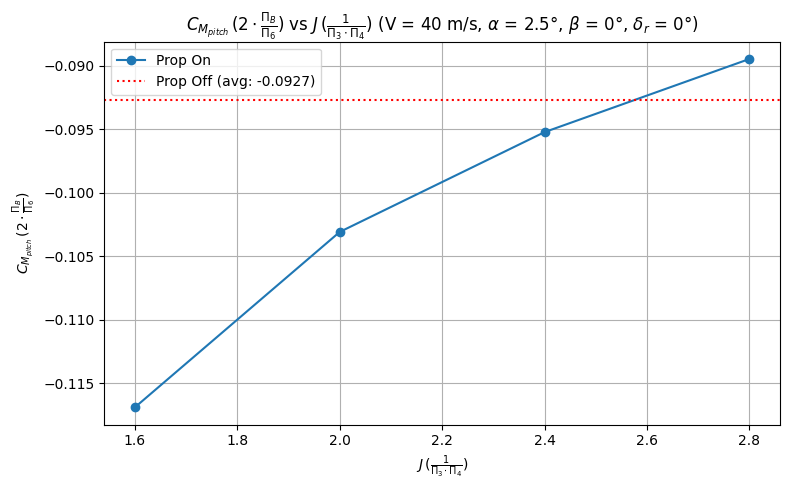

Saved to plot_images/CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png


In [13]:
import matplotlib.pyplot as plt

# Filter prop on
df_on_j = df[
    (df["V_round"] == 40) & 
    (df["AoA_round"] == 2.5) &
    (df["AoS_round"] == 0) &
    (df["dR"] == 0)
].sort_values("J_round")

# Filter prop off and average
df_off_j = df_prop_off[
    (df_prop_off["V_round"] == 40) & 
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
]

cmpitch_off_avg = df_off_j["CMpitch_FINAL"].mean() if not df_off_j.empty else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_on_j["J_round"],
    df_on_j["CMpitch_FINAL"],
    marker="o",
    linestyle="-",
    label="Prop On"
)

if cmpitch_off_avg is not None:
    ax.axhline(
        y=cmpitch_off_avg, 
        color='r', 
        linestyle=':', 
        label=f"Prop Off (avg: {cmpitch_off_avg:.4f})"
    )

ax.set_xlabel(r"$J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$")
ax.set_ylabel(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$")
ax.set_title(r"$C_{M_{pitch}} \, (2 \cdot \frac{\Pi_B}{\Pi_6})$ vs $J \, (\frac{1}{\Pi_3 \cdot \Pi_4})$ (V = 40 m/s, $\alpha$ = 2.5°, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plot_images/CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png", dpi=150)
plt.show()
print("Saved to plot_images/CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png")